In [33]:
# Emotion Sequence Modeling using LSTM
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [38]:
# --- CONFIG ---
SEQUENCE_FILE = Path("../data/processed/all_emotions.csv")
LABEL_FILE = Path("../data/processed/video_emotion_stats.csv")
SEQUENCE_CACHE = Path("../data/processed/sequence_cache.npz")
MAX_SEQ_LEN = 128
BATCH_SIZE = 64
EPOCHS = 10
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")

In [20]:
# --- Load DataFrames ---
print("Loading data...")
all_emotions = pd.read_csv(SEQUENCE_FILE)
label_df = pd.read_csv(LABEL_FILE)

Loading data...


In [21]:
# Get unique emotion columns (excluding metadata)
EMOTION_COLUMNS = [col for col in all_emotions.columns if col not in ['start', 'end', 'text', 'time', 'video_id']]
TARGET_COLUMNS = ['viewCount', 'likeCount', 'commentCount']

In [36]:
all_emotions.columns

Index(['start', 'end', 'text', 'time', 'admiration', 'amusement', 'anger',
       'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire',
       'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral', 'video_id'],
      dtype='object')

In [37]:
label_df.columns

Index(['admiration_mean', 'admiration_std', 'admiration_max', 'amusement_mean',
       'amusement_std', 'amusement_max', 'anger_mean', 'anger_std',
       'anger_max', 'annoyance_mean', 'annoyance_std', 'annoyance_max',
       'approval_mean', 'approval_std', 'approval_max', 'caring_mean',
       'caring_std', 'caring_max', 'confusion_mean', 'confusion_std',
       'confusion_max', 'curiosity_mean', 'curiosity_std', 'curiosity_max',
       'desire_mean', 'desire_std', 'desire_max', 'disappointment_mean',
       'disappointment_std', 'disappointment_max', 'disapproval_mean',
       'disapproval_std', 'disapproval_max', 'disgust_mean', 'disgust_std',
       'disgust_max', 'embarrassment_mean', 'embarrassment_std',
       'embarrassment_max', 'excitement_mean', 'excitement_std',
       'excitement_max', 'fear_mean', 'fear_std', 'fear_max', 'gratitude_mean',
       'gratitude_std', 'gratitude_max', 'grief_mean', 'grief_std',
       'grief_max', 'joy_mean', 'joy_std', 'joy_max', 'love_mean'

In [22]:
# Group sequences per video
def build_sequence(video_df):
    seq = video_df[EMOTION_COLUMNS].values
    if len(seq) >= MAX_SEQ_LEN:
        return seq[:MAX_SEQ_LEN]
    else:
        pad = np.zeros((MAX_SEQ_LEN - len(seq), len(EMOTION_COLUMNS)))
        return np.vstack((seq, pad))

In [23]:
# Load or build sequences
if SEQUENCE_CACHE.exists():
    cache = np.load(SEQUENCE_CACHE, allow_pickle=True)
    X = torch.tensor(np.array(cache['X'].tolist()), dtype=torch.float32)
    y = torch.tensor(np.array(cache['y'].tolist()), dtype=torch.float32)
    print("Loaded cached sequences.")
else:
    video_ids = all_emotions['video_id'].unique()
    X = []
    y = []
    label_df = label_df.set_index('video_id')

    print("Preparing sequences...")
    for vid in tqdm(video_ids):
        vdf = all_emotions[all_emotions['video_id'] == vid]
        if vid in label_df.index:
            target_row = label_df.loc[vid, TARGET_COLUMNS]
            
            try:
                target_vals = target_row.astype(np.float32).values
                if np.all(np.isfinite(target_vals)):
                    X.append(build_sequence(vdf))
                    y.append(target_vals)
            except Exception as e:
                print(f"Skipping {vid} due to type error: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    
    np.savez(SEQUENCE_CACHE, X=X, y=y)

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

print(f"Prepared {len(X)} sequences.")

Preparing sequences...


100%|██████████| 26180/26180 [51:06<00:00,  8.54it/s]    


Prepared 26180 sequences.


In [24]:
# --- Normalize features and targets ---
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_shape = X.shape
X = X.view(-1, X.shape[-1])
X = torch.tensor(scaler_x.fit_transform(X), dtype=torch.float32).view(*X_shape)
y = torch.tensor(scaler_y.fit_transform(y), dtype=torch.float32)

In [25]:
# --- SPLIT DATASET ---
total_size = len(X)
test_size = int(0.05 * total_size)
val_size = int(0.15 * total_size)
train_size = total_size - val_size - test_size

indices = torch.randperm(total_size)
X_train, y_train = X[indices[:train_size]], y[indices[:train_size]]
X_val, y_val = X[indices[train_size:train_size+val_size]], y[indices[train_size:train_size+val_size]]
X_test, y_test = X[indices[train_size+val_size:]], y[indices[train_size+val_size:]]

train_dl = DataLoader(list(zip(X_train, y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(list(zip(X_val, y_val)), batch_size=BATCH_SIZE)
test_dl = DataLoader(list(zip(X_test, y_test)), batch_size=BATCH_SIZE)

In [31]:
# --- MODEL ---
class EmotionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=3, output_size=3, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.fc1 = nn.Linear(hidden_size * 2, 128)
        self.fc2 = nn.Linear(128, output_size)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        x = torch.cat((hn[-2], hn[-1]), dim=1)  # concatenate bidirectional
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = EmotionLSTM(input_size=len(EMOTION_COLUMNS), output_size=len(TARGET_COLUMNS)).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [34]:
# --- TRAIN ---
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb)
        loss = torch.sqrt(criterion(pred, yb))  # RMSE
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_loss += torch.sqrt(criterion(pred, yb)).item()

    avg_train_loss = total_loss / len(train_dl)
    avg_val_loss = val_loss / len(val_dl)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

Epoch 1: Train Loss = 0.6384, Val Loss = 0.7057
Epoch 2: Train Loss = 0.6399, Val Loss = 0.7249
Epoch 3: Train Loss = 0.6460, Val Loss = 0.7062
Epoch 4: Train Loss = 0.6449, Val Loss = 0.7080
Epoch 5: Train Loss = 0.6393, Val Loss = 0.7061
Epoch 6: Train Loss = 0.6287, Val Loss = 0.7074
Epoch 7: Train Loss = 0.6392, Val Loss = 0.7039
Epoch 8: Train Loss = 0.6462, Val Loss = 0.7067
Epoch 9: Train Loss = 0.6374, Val Loss = 0.7010
Epoch 10: Train Loss = 0.6237, Val Loss = 0.7023


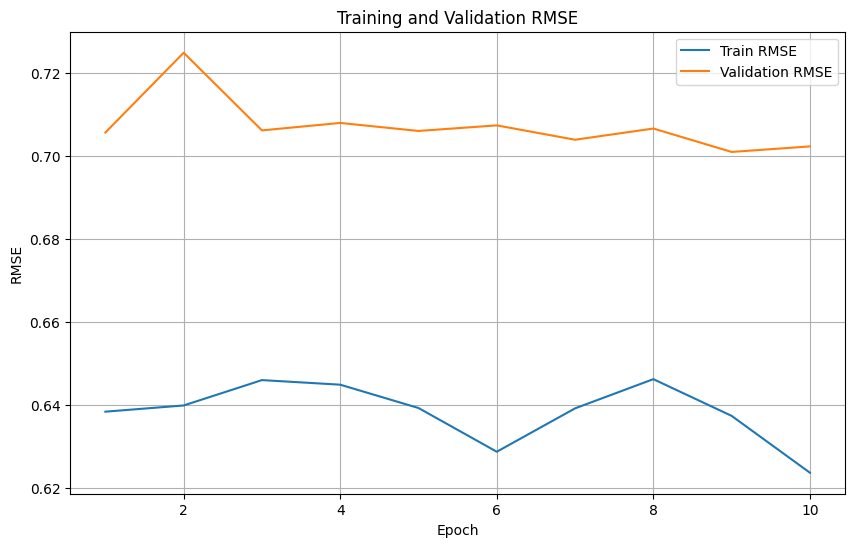

In [35]:
# --- Plot Training Graph ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train MSE")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training and Validation MSE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- TEST EVALUATION ---
model.eval()
test_loss = 0
with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb)
        test_loss += torch.sqrt(criterion(pred, yb)).item()

print(f"\nFinal Test RMSE = {test_loss/len(test_dl):.4f}")
print("Training complete.")


Final Test Loss = 334133566844.9524
